# Análisis inicial de `bodyPerformance`

Este notebook sigue una primera pasada de CRISP-DM centrada en la comprensión de datos. El objetivo de esta práctica es construir la matriz de correlación y empezar a ver qué variables se relacionan más con `body fat_%`.

Más adelante podremos ordenar, filtrar y ampliar el análisis; por ahora nos quedamos con esta base exploratoria.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.3f}')

file_path = 'bodyPerformance.csv'
df = pd.read_csv(file_path)

print(f'Filas: {df.shape[0]}')
print(f'Columnas: {df.shape[1]}')
df.head()

Filas: 13393
Columnas: 12


,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,27.000,M,172.300,75.240,21.300,80.000,130.000,54.900,18.400,60.000,217.000,C
1,25.000,M,165.000,55.800,15.700,77.000,126.000,36.400,16.300,53.000,229.000,A
2,31.000,M,179.600,78.000,20.100,92.000,152.000,44.800,12.000,49.000,181.000,C
3,32.000,M,174.500,71.100,18.400,76.000,147.000,41.400,15.200,53.000,219.000,B
4,28.000,M,173.800,67.700,17.100,70.000,127.000,43.500,27.100,45.000,217.000,B


## 1. Carga y exploración de datos

Primero revisamos la estructura general del dataset para entender qué variables tenemos y cuáles serán útiles para la correlación.

In [2]:
df.info()
print()
print('Valores faltantes por columna:')
print(df.isna().sum())
print()
print('Duplicados:', df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13393 entries, 0 to 13392
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      13393 non-null  float64
 1   gender                   13393 non-null  object 
 2   height_cm                13393 non-null  float64
 3   weight_kg                13393 non-null  float64
 4   body fat_%               13393 non-null  float64
 5   diastolic                13393 non-null  float64
 6   systolic                 13393 non-null  float64
 7   gripForce                13393 non-null  float64
 8   sit and bend forward_cm  13393 non-null  float64
 9   sit-ups counts           13393 non-null  float64
 10  broad jump_cm            13393 non-null  float64
 11  class                    13393 non-null  object 
dtypes: float64(10), object(2)
memory usage: 1.2+ MB

Valores faltantes por columna:
age                        0
gender               

## 2. Preparación de datos

Para la correlación usamos columnas numéricas y también codificamos `gender` y `class` para poder incluirlas en la matriz. Además, eliminamos duplicados si existieran y dejamos todo listo para el análisis.

In [7]:
df_corr = df.drop_duplicates().copy()

categorical_cols = ['gender', 'class']
for col in categorical_cols:
    if col in df_corr.columns and not pd.api.types.is_numeric_dtype(df_corr[col]):
        df_corr[col] = df_corr[col].astype('category').cat.codes

numeric_cols = df_corr.select_dtypes(include='number').columns.tolist()
df_numeric = df_corr[numeric_cols].copy()

print('Columnas numéricas usadas para correlación:')
print(numeric_cols)
print()
print('Codificación aplicada a variables categóricas:')
for col in categorical_cols:
    if col in df.columns and not pd.api.types.is_numeric_dtype(df[col]):
        print(f'  - {col}: codificada como categoría entera')
print()
print(f'Dimensiones después de limpiar duplicados: {df_corr.shape}')

Columnas numéricas usadas para correlación:
['age', 'gender', 'height_cm', 'weight_kg', 'body fat_%', 'diastolic', 'systolic', 'gripForce', 'sit and bend forward_cm', 'sit-ups counts', 'broad jump_cm', 'class']

Codificación aplicada a variables categóricas:
  - gender: codificada como categoría entera
  - class: codificada como categoría entera

Dimensiones después de limpiar duplicados: (13392, 12)


## 3. Cálculo de la matriz de correlación

Aquí calculamos la matriz de correlación con las variables numéricas para ver relaciones lineales entre las características.

In [10]:
corr_matrix = df_numeric.corr()
corr_matrix

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
age,1.000,-0.060,-0.294,-0.100,0.242,0.158,0.211,-0.180,-0.070,-0.545,-0.435,0.066
gender,-0.060,1.000,0.731,0.673,-0.551,0.228,0.324,0.800,-0.327,0.475,0.704,0.075
height_cm,-0.294,0.731,1.000,0.735,-0.515,0.146,0.210,0.735,-0.222,0.501,0.675,0.038
weight_kg,-0.100,0.673,0.735,1.000,-0.084,0.262,0.339,0.700,-0.296,0.295,0.480,0.214
body fat_%,0.242,-0.551,-0.515,-0.084,1.000,0.048,-0.030,-0.542,-0.071,-0.609,-0.673,0.342
diastolic,0.158,0.228,0.146,0.262,0.048,1.000,0.676,0.202,-0.072,0.017,0.097,0.067
systolic,0.211,0.324,0.210,0.339,-0.030,0.676,1.000,0.286,-0.082,0.056,0.153,0.035
gripForce,-0.180,0.800,0.735,0.700,-0.542,0.202,0.286,1.000,-0.113,0.577,0.747,-0.136
sit and bend forward_cm,-0.070,-0.327,-0.222,-0.296,-0.071,-0.072,-0.082,-0.113,1.000,0.177,0.027,-0.588
sit-ups counts,-0.545,0.475,0.501,0.295,-0.609,0.017,0.056,0.577,0.177,1.000,0.748,-0.453


## 4. Visualización de la matriz de correlación

El mapa de calor ayuda a identificar rápidamente las relaciones más fuertes entre variables.

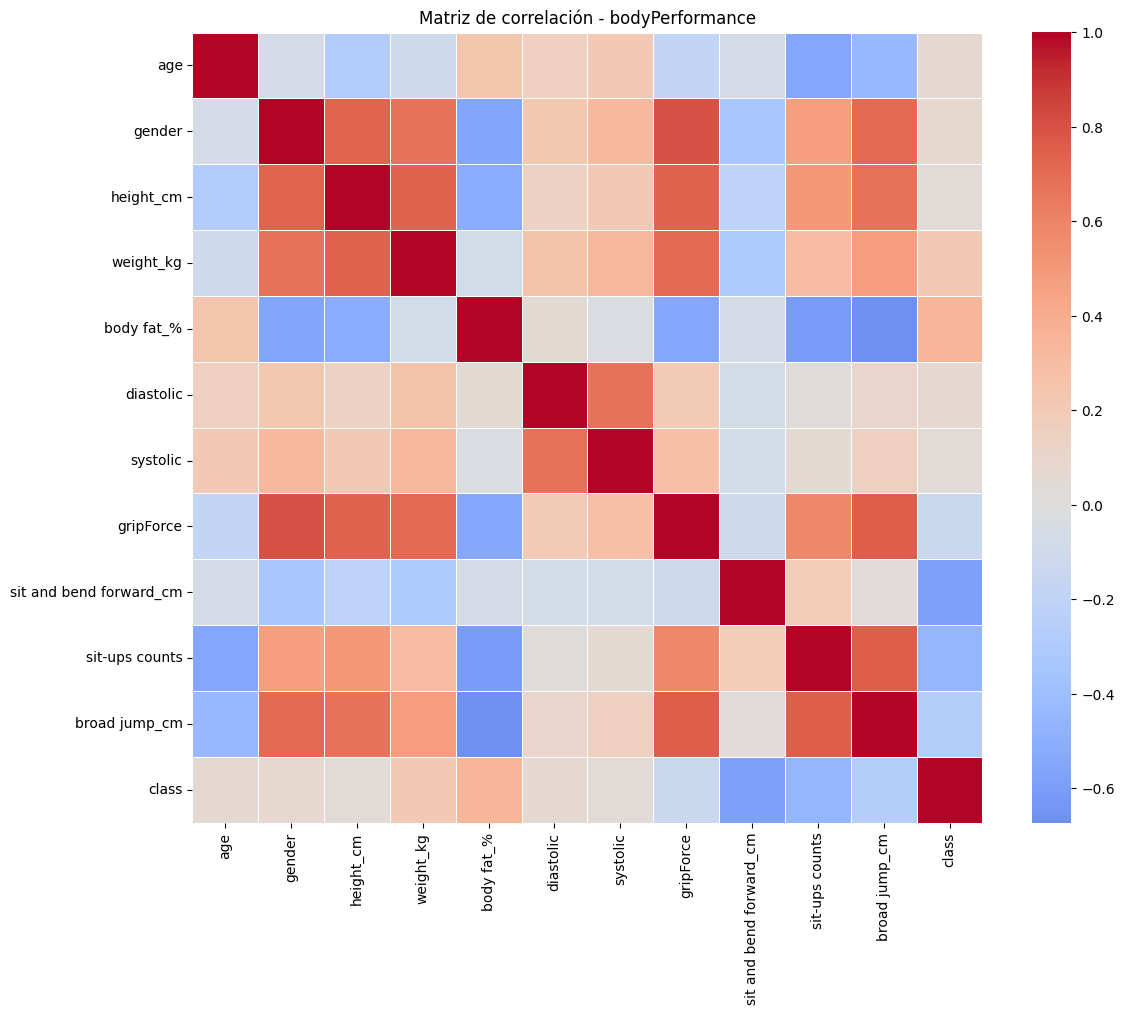

In [11]:
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Matriz de correlación - bodyPerformance')
plt.tight_layout()
plt.show()

## 5. Variables relacionadas con `body fat_%`

Como primer paso para identificar las características más importantes, revisamos qué variables tienen mayor correlación lineal con la grasa corporal.

In [12]:
target_col = 'body fat_%'
correlation_with_target = (
    corr_matrix[target_col]
    .drop(target_col)
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

print(f'Correlaciones con {target_col}:')
print(correlation_with_target)

correlation_with_target.to_frame(name='correlation')

Correlaciones con body fat_%:
broad jump_cm             -0.673
sit-ups counts            -0.609
gender                    -0.551
gripForce                 -0.542
height_cm                 -0.515
class                      0.342
age                        0.242
weight_kg                 -0.084
sit and bend forward_cm   -0.071
diastolic                  0.048
systolic                  -0.030
Name: body fat_%, dtype: float64


,correlation
broad jump_cm,-0.673
sit-ups counts,-0.609
gender,-0.551
gripForce,-0.542
height_cm,-0.515
class,0.342
age,0.242
weight_kg,-0.084
sit and bend forward_cm,-0.071
diastolic,0.048


### Interpretación breve de las relaciones más fuertes

Las relaciones más fuertes con `body fat_%` son `broad jump_cm` (-0.673), `sit-ups counts` (-0.609), `gender` (-0.551), `gripForce` (-0.542) y `height_cm` (-0.515). En términos simples, estas correlaciones negativas indican que, a medida que suben estas variables, el porcentaje de grasa tiende a bajar. Por ejemplo, mejor rendimiento físico en salto, abdominales y fuerza de agarre suele aparecer asociado con menor grasa corporal.

`class` también aparece con una correlación positiva moderada (0.342), así que puede aportar información, aunque su relación es menos fuerte que la de las variables anteriores. `age` tiene una relación positiva más suave (0.242), lo que sugiere una tendencia leve a aumentar con la edad.

Esto sigue siendo una relación lineal y no implica causalidad; sirve como primer filtro para entender qué variables parecen más relevantes.